<h2>Exercise 06: Scatter Matrix</h2>

In [1]:
import pandas as pd 
import sqlite3
from pandas.plotting import scatter_matrix

In [2]:
# import sys
# !{sys.executable} -m pip install --upgrade --force-reinstall pandas

# !pip uninstall pandas -y
# !pip install pandas==2.2.2

### Preprocessing

In [22]:
df_csv = pd.read_csv("../data/ab-test.csv")
conn = sqlite3.connect("../data/checking-logs.sqlite")
conn_t = sqlite3.connect("/Users/artempausov/Desktop/School 21/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/test_123/DSB8_SQL_Pandas.ID_1577673-1/src/data/checking-logs.sqlite")

In [4]:
df_checker = pd.io.sql.read_sql(
    """
    SELECT 
        *
    FROM checker
    WHERE uid LIKE "user_%" and labname NOT LIKE "project1"
    """,
    conn
)

df_checker

,index,status,success,timestamp,numTrials,labname,uid
0,21,ready,0,2020-04-17 11:33:17.366400,1,laba04,user_4
1,22,checking,0,2020-04-17 11:40:05.103116,2,laba04,user_4
2,23,ready,0,2020-04-17 11:40:05.237273,2,laba04,user_4
3,24,checking,0,2020-04-17 11:44:20.541374,3,laba04,user_4
4,25,ready,1,2020-04-17 11:44:20.707058,3,laba04,user_4
...,...,...,...,...,...,...,...
1307,3397,ready,0,2020-05-21 20:19:06.872761,7,laba06s,user_1
1308,3398,checking,0,2020-05-21 20:22:41.785725,8,laba06s,user_1
1309,3399,ready,0,2020-05-21 20:22:41.877806,8,laba06s,user_1
1310,3400,checking,0,2020-05-21 20:37:00.129678,9,laba06s,user_1


In [5]:
df_pageviews = pd.io.sql.read_sql(
    """
    SELECT 
        *
    FROM pageviews
    WHERE uid LIKE "user_%"
    """,
    conn
)
df_pageviews

,index,uid,datetime
0,12,user_30,2020-04-17 22:46:26.785035
1,14,user_14,2020-04-18 10:53:52.623447
2,15,user_17,2020-04-18 10:56:55.833899
3,16,user_14,2020-04-18 10:57:37.331258
4,18,user_17,2020-04-18 12:05:48.200144
...,...,...,...
982,1073,user_28,2020-05-21 18:45:20.441142
983,1074,user_19,2020-05-21 23:03:06.457819
984,1075,user_25,2020-05-21 23:23:49.995349
985,1078,user_5,2020-05-22 11:30:18.368990


In [6]:
df_dealines = pd.io.sql.read_sql(
    """
    SELECT
        *
    FROM deadlines
    WHERE labs != "project1"
    """,
    conn,
    parse_dates=["deadlines"]
)

df_dealines.rename(columns={"labs": "labname"}, inplace=True)
df_dealines.drop('index', inplace=True, axis='columns')
df_dealines

,labname,deadlines
0,laba04,2020-04-26 23:59:59
1,laba04s,2020-04-26 23:59:59
2,laba05,2020-05-03 23:59:59
3,laba06,2020-05-24 23:59:59
4,laba06s,2020-05-24 23:59:59


In [7]:
df_csv

,uid,diff,time,group
0,user_1,-103.333333,after,test
1,user_1,-6.000000,before,test
2,user_18,-10.000000,after,test
3,user_18,-3.500000,before,test
4,user_19,-82.333333,after,test
5,user_19,-148.000000,before,test
6,user_21,-78.500000,after,test
7,user_21,-112.500000,before,test
8,user_25,-127.500000,after,test
9,user_25,-69.333333,before,test


In [8]:
min_commit_time = df_checker.groupby(['uid', 'labname'])['timestamp'].min().reset_index()
min_commit_time

,uid,labname,timestamp
0,user_0,lab02,2020-04-20 17:56:45.209722
1,user_1,code_rvw,2020-04-26 19:06:58.949373
2,user_1,lab05s,2020-05-03 20:27:06.316718
3,user_1,laba04,2020-04-26 17:06:18.462708
4,user_1,laba04s,2020-04-26 17:12:11.843671
...,...,...,...
146,user_8,laba04,2020-04-18 21:53:36.058389
147,user_8,laba04s,2020-04-19 10:22:35.761944
148,user_8,laba05,2020-05-02 13:28:07.705193
149,user_8,laba06,2020-05-16 17:56:15.755553


In [9]:
diff = pd.merge(min_commit_time, df_dealines, on='labname', how='left')
# Привести timestamp к datetime, если еще не
diff['timestamp'] = pd.to_datetime(diff['timestamp'])
# Привести deadlines к datetime
diff['deadlines'] = pd.to_datetime(diff['deadlines'])
diff['diff'] = (diff['timestamp'] - diff['deadlines']) / pd.Timedelta(hours=1)
diff.dropna(inplace=True)
diff

,uid,labname,timestamp,deadlines,diff
3,user_1,laba04,2020-04-26 17:06:18.462708,2020-04-26 23:59:59,-6.894594
4,user_1,laba04s,2020-04-26 17:12:11.843671,2020-04-26 23:59:59,-6.796432
5,user_1,laba05,2020-05-02 19:15:18.540185,2020-05-03 23:59:59,-28.744572
6,user_1,laba06,2020-05-17 16:26:35.268534,2020-05-24 23:59:59,-175.556592
7,user_1,laba06s,2020-05-20 12:23:37.289724,2020-05-24 23:59:59,-107.606031
...,...,...,...,...,...
146,user_8,laba04,2020-04-18 21:53:36.058389,2020-04-26 23:59:59,-194.106373
147,user_8,laba04s,2020-04-19 10:22:35.761944,2020-04-26 23:59:59,-181.623122
148,user_8,laba05,2020-05-02 13:28:07.705193,2020-05-03 23:59:59,-34.530915
149,user_8,laba06,2020-05-16 17:56:15.755553,2020-05-24 23:59:59,-198.062012


In [10]:
mean_diff = diff.groupby("uid")["diff"].mean().reset_index()
mean_diff.rename(columns={"diff":"avg_diff"}, inplace=True)
mean_diff

,uid,avg_diff
0,user_1,-65.119644
1,user_10,-75.242310
2,user_11,-2.884175
3,user_12,-89.450688
4,user_13,-48.878198
5,user_14,-159.568696
6,user_15,-18.092892
7,user_16,-39.336201
8,user_17,-62.207513
9,user_18,-6.367907


In [11]:
df_csv_test = df_csv[df_csv["group"]=="test"]
df_test = df_csv_test.groupby("uid")["diff"].mean().reset_index(name='mean_diff')
df_test_t = df_test["uid"]

In [12]:
stats_checker = df_checker.groupby("uid").size().reset_index(name="commits")
stats_checker

,uid,commits
0,user_0,3
1,user_1,62
2,user_10,20
3,user_11,7
4,user_12,86
5,user_13,52
6,user_14,61
7,user_15,23
8,user_16,41
9,user_17,51


In [13]:
stats_views = df_pageviews.groupby("uid").size().reset_index(name="pageviews")
stats_views

,uid,pageviews
0,user_1,28
1,user_10,89
2,user_14,143
3,user_17,47
4,user_18,3
5,user_19,16
6,user_21,10
7,user_25,179
8,user_28,149
9,user_3,317


In [14]:
result = pd.merge(df_test_t, mean_diff, on="uid", how="left")
result = pd.merge(result, stats_views, on="uid", how="left")
result = pd.merge(result, stats_checker, on="uid", how="left")
result

,uid,avg_diff,pageviews,commits
0,user_1,-65.119644,28,62
1,user_18,-6.367907,3,5
2,user_19,-99.440298,16,118
3,user_21,-96.111041,10,65
4,user_25,-93.474751,179,79
5,user_28,-86.793652,149,60
6,user_3,-105.738041,317,18


### Result

In [15]:
# !pip install scipy

array([[<Axes: xlabel='avg_diff', ylabel='avg_diff'>,
        <Axes: xlabel='pageviews', ylabel='avg_diff'>,
        <Axes: xlabel='commits', ylabel='avg_diff'>],
       [<Axes: xlabel='avg_diff', ylabel='pageviews'>,
        <Axes: xlabel='pageviews', ylabel='pageviews'>,
        <Axes: xlabel='commits', ylabel='pageviews'>],
       [<Axes: xlabel='avg_diff', ylabel='commits'>,
        <Axes: xlabel='pageviews', ylabel='commits'>,
        <Axes: xlabel='commits', ylabel='commits'>]], dtype=object)

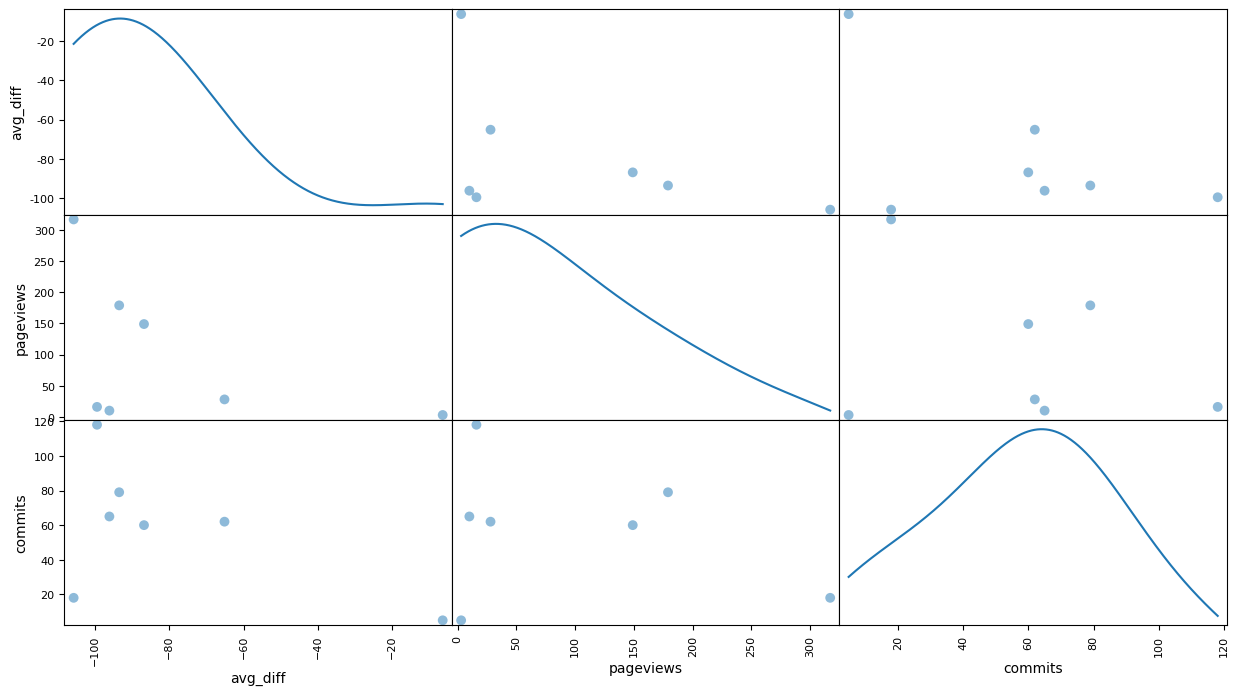

In [16]:
scatter_matrix(result, diagonal='kde', figsize=(15, 8), s=200, linewidth=3)

<h2>Answer</h2>
<h2>1. No</h2>
<h2>2. NO</h2>
<h2>3. Yes</h2>
<h2>4. No</h2>

In [20]:
conn.close()

### TEST

In [31]:
df_test_12 = pd.io.sql.read_sql(
    """ 
    SELECT 
        *
    FROM test
    WHERE labname NOT LIKE "project1"
    """,
    conn_t
)
df_test_12

,uid,labname,first_commit_ts,first_view_ts
0,user_30,laba04,2020-04-18 13:36:53.971502,2020-04-17 22:46:26.785035
1,user_30,laba04s,2020-04-18 14:51:37.498399,2020-04-17 22:46:26.785035
2,user_14,laba04,2020-04-18 15:14:00.312338,2020-04-18 10:53:52.623447
3,user_14,laba04s,2020-04-18 22:30:30.247628,2020-04-18 10:53:52.623447
4,user_19,laba04,2020-04-20 19:05:01.297780,2020-04-21 20:30:38.034966
5,user_25,laba04,2020-04-20 19:16:50.673054,2020-05-09 23:54:54.260791
6,user_21,laba04,2020-04-21 17:48:00.487806,2020-04-22 22:40:36.824081
7,user_21,laba04s,2020-04-22 20:09:21.857747,2020-04-22 22:40:36.824081
8,user_28,laba04,2020-04-22 21:47:19.707242,2020-05-10 21:07:50.350946
9,user_17,laba04,2020-04-23 14:24:29.947554,2020-04-18 10:56:55.833899


In [33]:
uid_test = df_test_12.groupby("uid").size()
uid_test

uid
user_1     5
user_10    5
user_14    3
user_17    5
user_18    3
user_19    4
user_21    4
user_25    5
user_28    5
user_3     5
user_30    4
dtype: int64

In [42]:
diff_test = pd.merge(df_test_12, min_commit_time, on='labname', how='left')
diff_test = pd.merge(diff_test, df_dealines, on='labname', how='left')
# Привести timestamp к datetime, если еще не
diff_test['timestamp'] = pd.to_datetime(diff_test['timestamp'])
# Привести deadlines к datetime
diff_test['deadlines'] = pd.to_datetime(diff_test['deadlines'])
diff_test['diff'] = (diff_test['timestamp'] - diff_test['deadlines']) / pd.Timedelta(hours=1)
diff_test.dropna(inplace=True)
diff_test

,uid_x,labname,first_commit_ts,first_view_ts,uid_y,timestamp,deadlines,diff
0,user_30,laba04,2020-04-18 13:36:53.971502,2020-04-17 22:46:26.785035,user_1,2020-04-26 17:06:18.462708,2020-04-26 23:59:59,-6.894594
1,user_30,laba04,2020-04-18 13:36:53.971502,2020-04-17 22:46:26.785035,user_10,2020-04-25 08:24:52.696624,2020-04-26 23:59:59,-39.585084
2,user_30,laba04,2020-04-18 13:36:53.971502,2020-04-17 22:46:26.785035,user_12,2020-04-18 17:07:51.767358,2020-04-26 23:59:59,-198.868676
3,user_30,laba04,2020-04-18 13:36:53.971502,2020-04-17 22:46:26.785035,user_13,2020-04-25 17:56:16.919886,2020-04-26 23:59:59,-30.061689
4,user_30,laba04,2020-04-18 13:36:53.971502,2020-04-17 22:46:26.785035,user_14,2020-04-18 15:14:00.312338,2020-04-26 23:59:59,-200.766302
...,...,...,...,...,...,...,...,...
1118,user_17,laba06s,2020-05-21 17:39:17.783615,2020-04-18 10:56:55.833899,user_3,2020-05-19 08:42:50.851878,2020-05-24 23:59:59,-135.285597
1119,user_17,laba06s,2020-05-21 17:39:17.783615,2020-04-18 10:56:55.833899,user_4,2020-05-18 17:36:11.688502,2020-05-24 23:59:59,-150.396475
1120,user_17,laba06s,2020-05-21 17:39:17.783615,2020-04-18 10:56:55.833899,user_6,2020-05-20 14:50:07.609937,2020-05-24 23:59:59,-105.164275
1121,user_17,laba06s,2020-05-21 17:39:17.783615,2020-04-18 10:56:55.833899,user_7,2020-05-20 23:05:37.742597,2020-05-24 23:59:59,-96.905905


In [43]:
mean_diff_test = diff.groupby("uid")["diff"].mean().reset_index()
mean_diff_test.rename(columns={"diff":"avg_diff"}, inplace=True)
mean_diff_test

,uid,avg_diff
0,user_1,-65.119644
1,user_10,-75.242310
2,user_11,-2.884175
3,user_12,-89.450688
4,user_13,-48.878198
5,user_14,-159.568696
6,user_15,-18.092892
7,user_16,-39.336201
8,user_17,-62.207513
9,user_18,-6.367907


In [46]:
df_test_12["uid"]

0     user_30
1     user_30
2     user_14
3     user_14
4     user_19
5     user_25
6     user_21
7     user_21
8     user_28
9     user_17
10     user_3
11     user_3
12    user_10
13    user_10
14    user_17
15    user_28
16     user_1
17     user_1
18    user_18
19    user_18
20    user_25
21    user_14
22     user_3
23    user_25
24    user_28
25    user_10
26    user_30
27    user_17
28    user_21
29    user_19
30     user_1
31    user_18
32     user_3
33     user_1
34    user_28
35    user_25
36     user_3
37    user_19
38    user_10
39    user_30
40    user_21
41    user_10
42     user_1
43    user_25
44    user_28
45    user_19
46    user_17
47    user_17
Name: uid, dtype: str

In [ ]:
df_csv_test = df_test_12["uid"]
df_test = df_csv_test.groupby("uid")["diff"].mean().reset_index(name='mean_diff')
df_test_t = df_test["uid"]

KeyError: "None of [Index(['user_30', 'user_30', 'user_14', 'user_14', 'user_19', 'user_25',\n       'user_21', 'user_21', 'user_28', 'user_17', 'user_3', 'user_3',\n       'user_10', 'user_10', 'user_17', 'user_28', 'user_1', 'user_1',\n       'user_18', 'user_18', 'user_25', 'user_14', 'user_3', 'user_25',\n       'user_28', 'user_10', 'user_30', 'user_17', 'user_21', 'user_19',\n       'user_1', 'user_18', 'user_3', 'user_1', 'user_28', 'user_25', 'user_3',\n       'user_19', 'user_10', 'user_30', 'user_21', 'user_10', 'user_1',\n       'user_25', 'user_28', 'user_19', 'user_17', 'user_17'],\n      dtype='str')] are in the [columns]"

In [ ]:
result = pd.merge(mean_diff_test, mean_diff, on="uid", how="left")
result = pd.merge(result, stats_views, on="uid", how="left")
result = pd.merge(result, stats_checker, on="uid", how="left")
result

,uid,avg_diff_x,avg_diff_y,pageviews,commits
0,user_1,-65.119644,-65.119644,28.0,62
1,user_10,-75.242310,-75.242310,89.0,20
2,user_11,-2.884175,-2.884175,NaN,7
3,user_12,-89.450688,-89.450688,NaN,86
4,user_13,-48.878198,-48.878198,NaN,52
5,user_14,-159.568696,-159.568696,143.0,61
6,user_15,-18.092892,-18.092892,NaN,23
7,user_16,-39.336201,-39.336201,NaN,41
8,user_17,-62.207513,-62.207513,47.0,51
9,user_18,-6.367907,-6.367907,3.0,5


In [54]:
selected_users = ["user_1", "user_10", "user_14", "user_17", "user_18", 
                  "user_19", "user_21", "user_25", "user_28", "user_3"]
result = result[result["uid"].isin(selected_users)]
result = result.drop("avg_diff_y", axis=1)
result

,uid,avg_diff_x,pageviews,commits
0,user_1,-65.119644,28.0,62
1,user_10,-75.242310,89.0,20
5,user_14,-159.568696,143.0,61
8,user_17,-62.207513,47.0,51
9,user_18,-6.367907,3.0,5
10,user_19,-99.440298,16.0,118
13,user_21,-96.111041,10.0,65
17,user_25,-93.474751,179.0,79
20,user_28,-86.793652,149.0,60
22,user_3,-105.738041,317.0,18


array([[<Axes: xlabel='avg_diff_x', ylabel='avg_diff_x'>,
        <Axes: xlabel='pageviews', ylabel='avg_diff_x'>,
        <Axes: xlabel='commits', ylabel='avg_diff_x'>],
       [<Axes: xlabel='avg_diff_x', ylabel='pageviews'>,
        <Axes: xlabel='pageviews', ylabel='pageviews'>,
        <Axes: xlabel='commits', ylabel='pageviews'>],
       [<Axes: xlabel='avg_diff_x', ylabel='commits'>,
        <Axes: xlabel='pageviews', ylabel='commits'>,
        <Axes: xlabel='commits', ylabel='commits'>]], dtype=object)

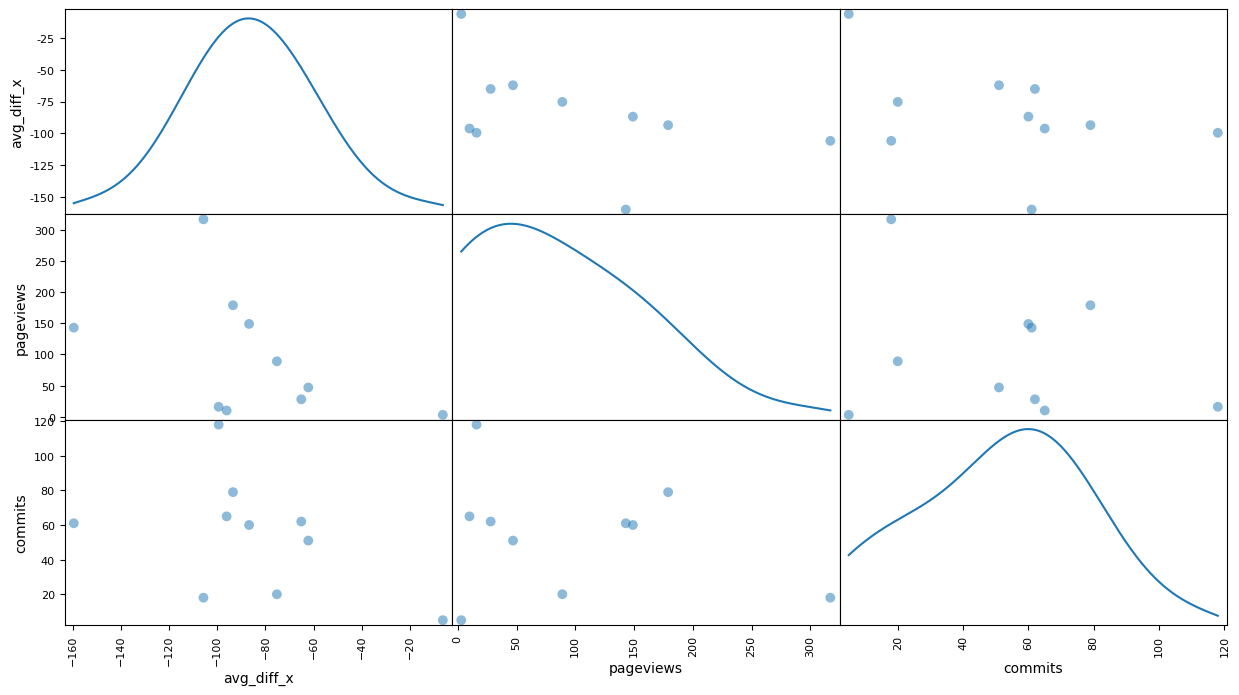

In [55]:
scatter_matrix(result, diagonal='kde', figsize=(15, 8), s=200, linewidth=3)